## Topic: Introduction of Logistic Regresssion

### 1. Introduction of Logistic Regresssion

- Defintion:
    - Logistic Regression is a binary Classification model that predict probabilities and makes clear, interpretable decision.

- Different between linear Regression and Logistic Regression.

    - 1. Linear Regression:
        - Predict any numbers on a continuous scale.
        - output cab be any value from (-ve infinite to +ve infinite).

        - eg: temperate, stock values, house price

    - 2. Logistic Regression:
        - Predict Probability between 0 to 1, then convert it into a clear class label.

        - Create a 's' curve that represent the predicte values in range (0-1)

- NOTE:
    - Logistic Regression use sigmoid Function to squeeze all o/p into valid range(0 to 1).

    
- The Logistic Regression Pipeline:
    - Step_1: Input features
        - x1, x2, x3......xn

    - Step_2: Linear Combination
        - z = w.x + b

    - Step_3: Sigmoid Function
        - o(z) = (1/1+e^-z)

    - Step_4: Probability
        - output value between 0 to 1.

    - Step_5: Theshold 
        - op >= 0.5 => Class 1
        - op < 0.5 => Class 2

## 2. Code Implementation

In [3]:
# import necessary libraries
# import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler


## 1. Load the Dataset

In [4]:
# load data

data = load_breast_cancer()

X_full = data.data
y_full = data.target

print("Features Metrics shape: ", X_full.shape)
print("Target shape: ", y_full.shape)
print("Classes name: ", data.target_names)

Features Metrics shape:  (569, 30)
Target shape:  (569,)
Classes name:  ['malignant' 'benign']


In [5]:
# Create a DataFrame for easier exploration

feature_names = data.feature_names

df = pd.DataFrame(X_full, columns = feature_names)

df['target'] = y_full

df.head(10)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


### 2. Quick EDA

In [6]:
# Explore the data with describe()

df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
# check null value
df.isnull().sum()

# there are no null value

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [8]:
# unique vaalue
df.nunique()

mean radius                456
mean texture               479
mean perimeter             522
mean area                  539
mean smoothness            474
mean compactness           537
mean concavity             537
mean concave points        542
mean symmetry              432
mean fractal dimension     499
radius error               540
texture error              519
perimeter error            533
area error                 528
smoothness error           547
compactness error          541
concavity error            533
concave points error       507
symmetry error             498
fractal dimension error    545
worst radius               457
worst texture              511
worst perimeter            514
worst area                 544
worst smoothness           411
worst compactness          529
worst concavity            539
worst concave points       492
worst symmetry             500
worst fractal dimension    535
target                       2
dtype: int64

In [9]:
# Check class Imbalance
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

- Explaination:
    - Features Can't contain Null values

    - Classes are not big imbalance


### 3. Train Logistic Regression

In [10]:
# import libraries

from sklearn.preprocessing import StandardScaler

# create an object
scaler = StandardScaler()

In [11]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size = 0.2, random_state = 42, stratify = y_full)


# Scaled and fit the train data
X_train_scaled = scaler.fit_transform(X_train)

# only scaled test data
X_test_scaled = scaler.transform(X_test)

print("Train Scaled Data shape: ", X_train_scaled.shape)

print("Test Scaled Data shape: ", X_test_scaled.shape)

Train Scaled Data shape:  (455, 30)
Test Scaled Data shape:  (114, 30)


### 4. Fit the logistic Regression Model

In [12]:
# Fit the logistic Regression Model

# create an object
model = LogisticRegression(max_iter = 100)

# fit the model on train scaled dataset
model.fit(X_train_scaled, y_train)

# Prediction on test scaled dataset
y_test_pred = model.predict(X_test_scaled)

# probability of Prediction
y_test_proba = model.predict_proba(X_test_scaled)[:,1]


# Accuracy 
acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy:{acc:.3f} ")


Test Accuracy:0.982 


In [16]:
# Now, see the Learn parameter of logistic model
print("Intercept (b): ", model.intercept_)
print("Coefficient (w): ", model.coef_)

Intercept (b):  [0.30220757]
Coefficient (w):  [[-0.51147901 -0.55269775 -0.47629789 -0.54105924 -0.21247927  0.64834159
  -0.60210291 -0.70415649 -0.16723273  0.19973173 -1.08296534  0.24882301
  -0.54433323 -0.92910402 -0.16027571  0.64722656  0.16056252 -0.44378424
   0.36049156  0.43789426 -0.94761615 -1.25508804 -0.76322007 -0.9477559
  -0.74662481  0.05551412 -0.82315065 -0.95368636 -0.93918141 -0.1872508 ]]


### 5. Inspect confusion Metrics and Classification report

In [13]:
# Confusion Metrics

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[41  1]
 [ 1 71]]


In [14]:
# Classification Report
print("Classification Report: \n", classification_report(y_test, y_test_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 6. Visual Confusion matrix

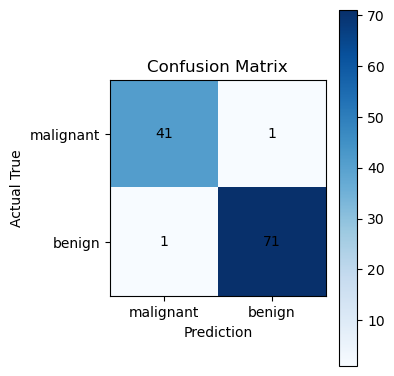

In [15]:
plt.figure(figsize = (4,4))

plt.imshow(cm, cmap = "Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_labels = data.target_names
plt.xticks([0,1], tick_labels)
plt.yticks([0,1], tick_labels)

plt.xlabel("Prediction")
plt.ylabel("Actual True")

# Add numbers to each cell
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j], ha="center", va="center", color = "black")

plt.tight_layout()
plt.show()

- Note:
    - Logistic Regression is giving a probability, not a raw pass or fail.

    - The predicted class comes after applying a threshold like 0.5.